In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Read CSV

In [ ]:
df = pd.read_csv("../data/raw/recipes_dataset.csv")
df.drop(columns=["url"], inplace=True)
df.to_csv("recipes_dataset.csv", index=False)

In [54]:
df.head()

,title,ingredients,calories
0,1-2-3-4 Coconut Cake,"1 cup salted butter, softened, 2 cups white su...",866
1,These 4-Ingredient Copycat 100 Grand Bars Are ...,"1 (12 ounce ) bag dark chocolate chips, divide...",298
2,15-Minute Butter Gnocchi with Spicy Chili Cris...,"2 pounds gnocchi, 6 tablespoons salted or unsa...",507
3,This 15-Minute Chicken Dinner Makes Weeknights...,"2 tablespoons hot honey, or more to taste, 2 t...",642
4,15-Minute Chili Crisp Noodles,"5 cups water, 2 (3 ounce) packages dry ramen n...",469


## Shape of the Data

In [55]:
df.shape

(20264, 3)

## Info of Data

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20264 entries, 0 to 20263
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        20264 non-null  object
 1   ingredients  20264 non-null  object
 2   calories     20264 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 475.1+ KB


## Check Nullity

In [57]:
print(df.isnull().sum())

title          0
ingredients    0
calories       0
dtype: int64


## Check Duplicate

In [58]:
print("Duplicate Titles:", df.duplicated(subset="title").sum())

Duplicate Titles: 76


## Confirming Duplicity

In [59]:
duplicates = df[df.duplicated(subset="title", keep=False)]

duplicates = duplicates.sort_values("title")

print(duplicates[["title"]].head(20))

                                title
10154  A Good and Easy Garlic Chicken
10153  A Good and Easy Garlic Chicken
12009    Asian Chicken Salad in a Jar
12008    Asian Chicken Salad in a Jar
182             Avocado Caprese Salad
183             Avocado Caprese Salad
8535       BBQ Chicken Tortilla Pizza
8536       BBQ Chicken Tortilla Pizza
10229         Baja-Style Chicken Bowl
10230         Baja-Style Chicken Bowl
17456       Banana Bread French Toast
231         Banana Bread French Toast
6163               Better Baked Beans
3676               Better Baked Beans
2011                  Blonde Brownies
2012                  Blonde Brownies
19319          Broccoli Chicken Divan
19318          Broccoli Chicken Divan
399            Butternut Squash Chili
398            Butternut Squash Chili


In [60]:
duplicates = df[df["title"] == "A Good and Easy Garlic Chicken"]

print(duplicates)

                                title  \
10153  A Good and Easy Garlic Chicken   
10154  A Good and Easy Garlic Chicken   

                                             ingredients  calories  
10153  3 tablespoons butter, 4 skinless, boneless chi...       214  
10154  3 tablespoons butter, 4 skinless, boneless chi...       214  


In [61]:
print("Complete duplicate rows:", df.duplicated().sum())

Complete duplicate rows: 39


## Drop Duplicity

In [62]:
df.drop_duplicates(inplace=True)
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 20225


## Handle Outliers

In [63]:
print("Rows before filtering:", len(df))

df = df[df["calories"] <= 1500].copy()
df.reset_index(drop=True, inplace=True)

print("Rows after filtering:", len(df))

Rows before filtering: 20225
Rows after filtering: 20177


In [64]:
df.describe()

,calories
count,20177.000000
mean,339.267879
std,213.250569
min,1.000000
25%,182.000000
50%,304.000000
75%,450.000000
max,1499.000000


## Distribution of Calories

### (Recepies vs Calories)

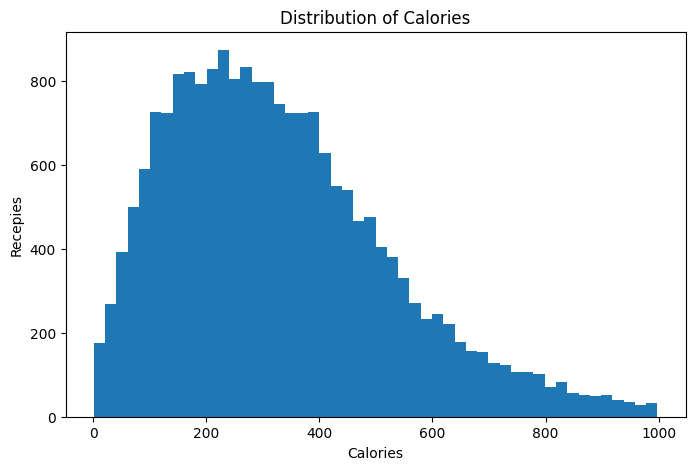

In [65]:
plt.figure(figsize=(8,5))

plt.hist(df[df["calories"] < 1000]["calories"], bins=50)

plt.xlabel("Calories")

plt.ylabel("Recepies")

plt.title("Distribution of Calories")

plt.show() 

## Check of Oultliier

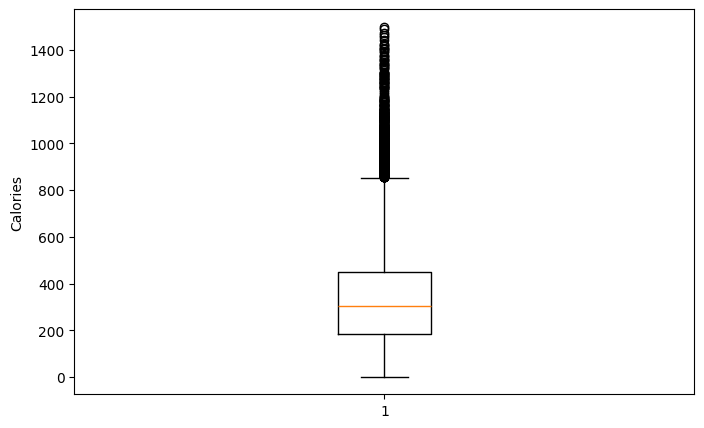

In [66]:
plt.figure(figsize=(8,5))

plt.boxplot(df["calories"])

plt.ylabel("Calories")

plt.show()

## Combining Title and ingredients

In [67]:
df["text"] = df["title"] + " " + df["ingredients"]

df[["title","ingredients","text"]].head()

,title,ingredients,text
0,1-2-3-4 Coconut Cake,"1 cup salted butter, softened, 2 cups white su...","1-2-3-4 Coconut Cake 1 cup salted butter, soft..."
1,These 4-Ingredient Copycat 100 Grand Bars Are ...,"1 (12 ounce ) bag dark chocolate chips, divide...",These 4-Ingredient Copycat 100 Grand Bars Are ...
2,15-Minute Butter Gnocchi with Spicy Chili Cris...,"2 pounds gnocchi, 6 tablespoons salted or unsa...",15-Minute Butter Gnocchi with Spicy Chili Cris...
3,This 15-Minute Chicken Dinner Makes Weeknights...,"2 tablespoons hot honey, or more to taste, 2 t...",This 15-Minute Chicken Dinner Makes Weeknights...
4,15-Minute Chili Crisp Noodles,"5 cups water, 2 (3 ounce) packages dry ramen n...","15-Minute Chili Crisp Noodles 5 cups water, 2 ..."


### Making lowercase to text column

In [68]:
df["text"] = df["text"].str.lower()

In [69]:
import re

df["text"] = df["text"].apply(
    lambda x: re.sub(r"[^a-z0-9\s]", " ", x)
)

df["text"] = df["text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

print(df["text"].iloc[0])

1 2 3 4 coconut cake 1 cup salted butter softened 2 cups white sugar divided 4 eggs room temperature separated 3 cups cake flour spooned and leveled 2 teaspoons baking powder 1 2 teaspoon baking soda 1 cup unsweetened coconut milk room temperature 1 teaspoon clear imitation vanilla extract 1 teaspoon coconut extract 1 cup sweetened shredded coconut 1 1 4 cups salted butter softened 5 cups confectioners sugar sifted 1 3 cup unsweetened coconut milk 1 1 2 teaspoons clear imitation vanilla extract 1 2 teaspoon coconut extract 2 cups sweetened shredded coconut


## Remove stopwords

In [70]:
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["text"] = df["text"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

print(df["text"].iloc[0])

1 2 3 4 coconut cake 1 cup salted butter softened 2 cups white sugar divided 4 eggs room temperature separated 3 cups cake flour spooned leveled 2 teaspoons baking powder 1 2 teaspoon baking soda 1 cup unsweetened coconut milk room temperature 1 teaspoon clear imitation vanilla extract 1 teaspoon coconut extract 1 cup sweetened shredded coconut 1 1 4 cups salted butter softened 5 cups confectioners sugar sifted 1 3 cup unsweetened coconut milk 1 1 2 teaspoons clear imitation vanilla extract 1 2 teaspoon coconut extract 2 cups sweetened shredded coconut


## Lemmitization

In [71]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

df["text"] = df["text"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

print(df["text"].iloc[0])

1 2 3 4 coconut cake 1 cup salted butter softened 2 cup white sugar divided 4 egg room temperature separated 3 cup cake flour spooned leveled 2 teaspoon baking powder 1 2 teaspoon baking soda 1 cup unsweetened coconut milk room temperature 1 teaspoon clear imitation vanilla extract 1 teaspoon coconut extract 1 cup sweetened shredded coconut 1 1 4 cup salted butter softened 5 cup confectioner sugar sifted 1 3 cup unsweetened coconut milk 1 1 2 teaspoon clear imitation vanilla extract 1 2 teaspoon coconut extract 2 cup sweetened shredded coconut


# Feature Engineering

## 1. Ingredient count

In [72]:
df["ingredient_count"] = df["ingredients"].apply(
    lambda x: len(x.split(","))
)

## 2. Number Count

In [73]:
df["number_count"] = df["text"].str.count(r"\d+") 

In [74]:
df["cup_count"] = df["text"].str.count("cup")

df["tbsp_count"] = df["text"].str.count("tablespoon|tbsp")

df["tsp_count"] = df["text"].str.count("teaspoon|tsp")

df["oz_count"] = df["text"].str.count("ounce|oz")

## 3. Ingredient flags

In [75]:
high_calorie = [
    "butter",
    "oil",
    "cream",
    "cheese",
    "mayonnaise",
    "bacon",
    "beef",
    "chocolate",
    "sugar",
    "nuts"
]

for item in high_calorie:
    df[f"has_{item}"] = (
        df["text"]
        .str.contains(item, regex=False)
        .astype(int)
    )
for item in high_calorie:
    df[f"{item}_count"] = df["text"].str.count(item)

## 4. Cooking method flags

In [76]:
methods = [
    "fried",
    "deep fried",
    "pan fried",
    "baked",
    "grilled",
    "roasted",
    "steamed",
    "boiled",
    "broiled",
    "smoked",
    "air fryer",
    "slow cooked",
    "pressure cooked",
    "stir fry",
    "sauteed"
]

for method in methods:
    col = method.replace(" ", "_")
    df[f"method_{col}"] = (
        df["text"]
        .str.contains(method, regex=False)
        .astype(int)
    ) 

## 5. Protein Flags

In [77]:
proteins = [
    "chicken",
    "beef",
    "pork",
    "fish",
    "shrimp",
    "salmon",
    "turkey"
]

for protein in proteins:
    df[f"has_{protein}"] = (
        df["text"]
        .str.contains(protein, regex=False)
        .astype(int)
    ) 

## 6. Common Food Flags

In [78]:
common_foods = [
    "egg",
    "milk",
    "flour",
    "rice",
    "potato",
    "pasta",
    "bread",
    "onion",
    "garlic",
    "tomato",
    "carrot",
    "spinach",
    "broccoli",
    "bean",
    "corn",
    "banana",
    "apple",
    "avocado"
]

for food in common_foods:
    df[f"has_{food}"] = (
        df["text"]
        .str.contains(food, regex=False)
        .astype(int)
    )

## 7. Dessert Flags

In [79]:
desserts = [
    "cake",
    "cookie",
    "brownie",
    "pie",
    "cupcake",
    "muffin",
    "ice cream",
    "pudding"
]

for dessert in desserts:

    col = dessert.replace(" ", "_")

    df[f"dessert_{col}"] = (
        df["text"]
        .str.contains(dessert, regex=False)
        .astype(int)
    )

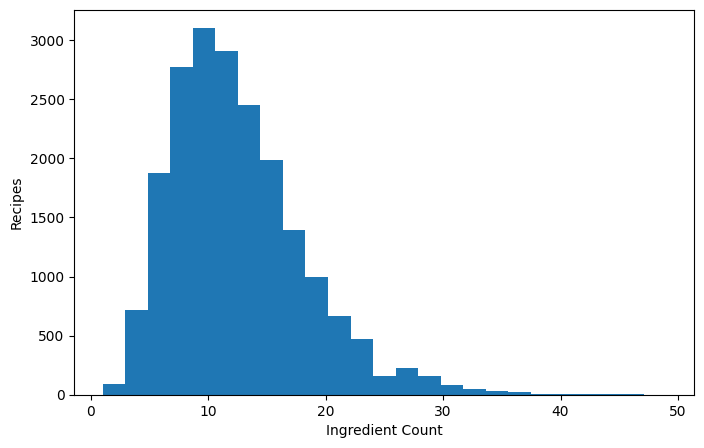

In [80]:
plt.figure(figsize=(8,5))

plt.hist(df["ingredient_count"], bins=25)

plt.xlabel("Ingredient Count")
plt.ylabel("Recipes")

plt.show() 

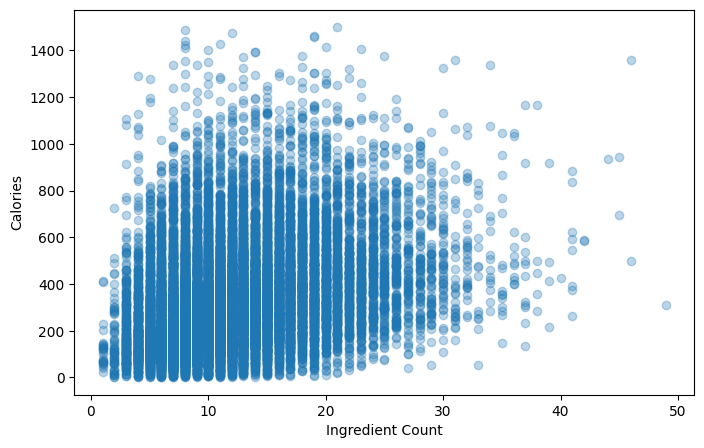

In [81]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["ingredient_count"],
    df["calories"],
    alpha=0.3
)

plt.xlabel("Ingredient Count")
plt.ylabel("Calories")

plt.show() 

## TF-IDF

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95
) 

In [83]:
X_word = tfidf.fit_transform(df["text"])
print(X_word.shape)

(20177, 40000)


In [84]:
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=15000
)

X_char = char_tfidf.fit_transform(df["text"])

print(X_char.shape)

(20177, 15000)


## Combine Features

In [85]:
numeric_cols = [
    "ingredient_count",
    "number_count",
    "cup_count",
    "tbsp_count",
    "tsp_count",
    "oz_count"
]

numeric_cols += [
    col 
    for col in df.columns
    if col.startswith("has_")
    or col.startswith("dessert_")
    or col.startswith("method_")
    or col.startswith("_count")
] 

In [86]:
X_numeric = df[numeric_cols] 

## X and Y Distribution

In [87]:
from scipy.sparse import hstack

X = hstack([
    X_word,
    X_char,
    X_numeric.values
])

In [88]:
y = df["calories"] 

## Train/Test Split

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Baseline Models

In [90]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=5)

ridge.fit(X_train, y_train)
pred = ridge.predict(X_valid)

In [91]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.metrics import r2_score

print("MAE:", mean_absolute_error(y_valid,pred))
print("RMSE:", root_mean_squared_error(y_valid,pred))
print("R²:", r2_score(y_valid,pred))

MAE: 111.76298501092549
RMSE: 152.14143840675155
R²: 0.4583055576706023


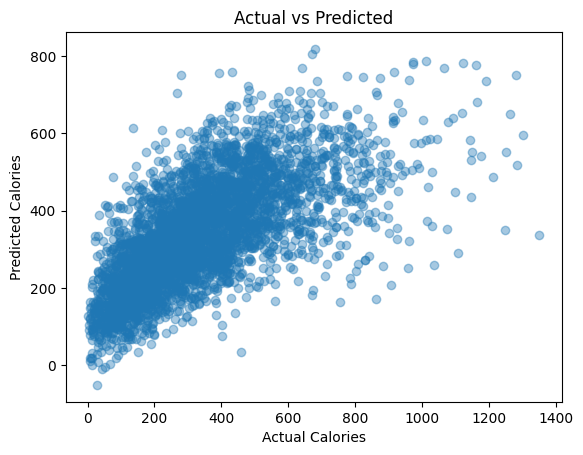

In [92]:
plt.scatter(y_valid, pred, alpha=0.4)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted")
plt.show() 

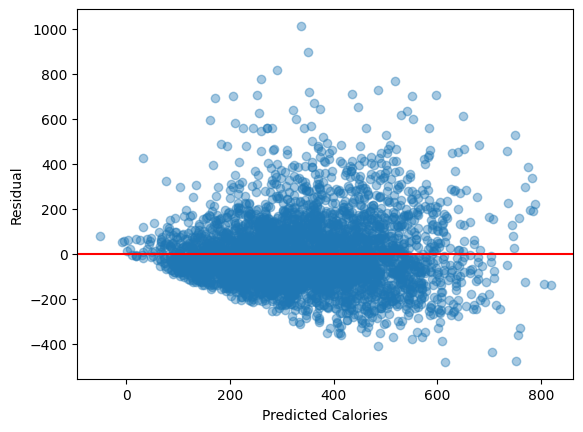

In [93]:
residual = y_valid - pred

plt.scatter(pred, residual, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Predicted Calories")
plt.ylabel("Residual")
plt.show() 

## Linear Regression

In [94]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_valid)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_valid, pred_lr))
print("RMSE:", root_mean_squared_error(y_valid, pred_lr))
print("R²  :", r2_score(y_valid, pred_lr))
print()

Linear Regression
MAE : 167.24251845485907
RMSE: 215.5625007911468
R²  : -0.08744116856113071



## Elastic Net

In [95]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    random_state=42
)

elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_valid)

print("Elastic Net")
print("MAE :", mean_absolute_error(y_valid, pred_elastic))
print("RMSE:", root_mean_squared_error(y_valid, pred_elastic))
print("R²  :", r2_score(y_valid, pred_elastic))
print()

Elastic Net
MAE : 113.0016374324974
RMSE: 153.42342069993182
R²  : 0.4491381872861768



/home/white_evil/Python_AI/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.456e+07, tolerance: 7.450e+04
  model = cd_fast.sparse_enet_coordinate_descent(


## Random Forest

In [96]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_valid)

print("Random Forest")
print("MAE :", mean_absolute_error(y_valid, pred_rf))
print("RMSE:", root_mean_squared_error(y_valid, pred_rf))
print("R²  :", r2_score(y_valid, pred_rf))
print()

Random Forest
MAE : 121.96295738354806
RMSE: 163.94582920535828
R²  : 0.3709863220809748



## XGBRegressor

In [97]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_valid)

print("XGBoost")
print("MAE :", mean_absolute_error(y_valid, pred_xgb))
print("RMSE:", root_mean_squared_error(y_valid, pred_xgb))
print("R²  :", r2_score(y_valid, pred_xgb))
print()

XGBoost
MAE : 117.47847747802734
RMSE: 157.96815490722656
R²  : 0.4160194396972656



## Comperison of Results

In [98]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Elastic Net",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_valid, pred_lr),
        mean_absolute_error(y_valid, pred),
        mean_absolute_error(y_valid, pred_elastic),
        mean_absolute_error(y_valid, pred_rf),
        mean_absolute_error(y_valid, pred_xgb)
    ],
    "RMSE": [
        root_mean_squared_error(y_valid, pred_lr),
        root_mean_squared_error(y_valid, pred),
        root_mean_squared_error(y_valid, pred_elastic),
        root_mean_squared_error(y_valid, pred_rf),
        root_mean_squared_error(y_valid, pred_xgb)
    ],
    "R²": [
        r2_score(y_valid, pred_lr),
        r2_score(y_valid, pred),
        r2_score(y_valid, pred_elastic),
        r2_score(y_valid, pred_rf),
        r2_score(y_valid, pred_xgb)
    ]
})

results = results.sort_values("RMSE")

print(results)

               Model         MAE        RMSE        R²
1              Ridge  111.762985  152.141438  0.458306
2        Elastic Net  113.001637  153.423421  0.449138
4            XGBoost  117.478477  157.968155  0.416019
3      Random Forest  121.962957  163.945829  0.370986
0  Linear Regression  167.242518  215.562501 -0.087441


In [ ]:
comparison = pd.DataFrame({
    "Recipe": df.loc[y_valid.index, "title"].values,
    "Actual Calories": y_valid.values,
    "Predicted Calories": pred
})

comparison["Absolute Error"] = (
    comparison["Actual Calories"] -
    comparison["Predicted Calories"]
).abs()

comparison.to_csv("data/processed/prediction_results.csv", index=False)
comparison = comparison.sort_values("Absolute Error")
comparison.head(20)

,Recipe,Actual Calories,Predicted Calories,Absolute Error
536,Dairy-Free Pumpkin Pie,153,152.952662,0.047338
664,Spicy Turkey Tacos,246,246.071946,0.071946
1581,My Favorite Chicken Salad,287,286.886903,0.113097
3589,Grandma&#39;s Collard Greens,181,180.827545,0.172455
701,Jelly Doughnut Cupcakes,246,246.179775,0.179775
3766,Instant Pot Lamb Tagine with Lentils,401,400.803235,0.196765
817,Baked Tilapia in Garlic and Olive Oil,217,216.786461,0.213539
3138,American Potato Salad,329,328.779581,0.220419
3710,Zucchini Pizza Bake,409,408.771277,0.228723
564,Jalapeño Popper Creamed Corn,400,399.750470,0.249530


## Saving of Model

In [ ]:
import joblib

joblib.dump(ridge, "models/ridge_calorie_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
joblib.dump(tfidf, "models/word_tfidf.pkl")
joblib.dump(char_tfidf, "models/char_tfidf.pkl")

In [ ]:
results.to_csv("data/model_comparison.csv", index=False)